### imports:

In [116]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable


# F1)
Solve:

$$\frac{dy}{dt} = 1 + t - y, \quad y(0) = 1, \quad t \in [0, 1.2]$$

## F1.a)


We have the definition of the derivative from above, we plot the directional field by evaluating the derivative at a grid of points.

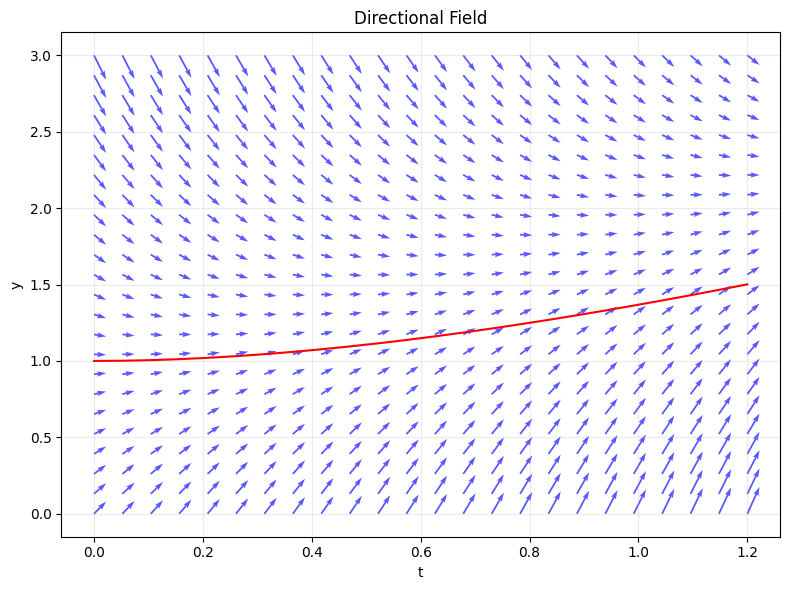

In [117]:
# directional field
t = np.linspace(0, 1.2, 24)
y = np.linspace(-0, 3, 24)
T, Y = np.meshgrid(t, y)
dY = 1 + T - Y
dT = np.ones_like(dY)

# Analytical solution
y_actual = np.exp(-t) + t


# uncomment this to normalize arrows in the plot but i think it resulted in a worse graph.
# L = np.sqrt(dT**2 + dY**2)
# dT = dT / L
# dY = dY / L


# Plot
plt.figure(figsize=(8, 6))
plt.quiver(T, Y, dT, dY, color="blue", alpha=0.65)
plt.plot(t, y_actual, color="red")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Directional Field")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## F1.b)

Write a python program that solves DE1 using Euler forward $$DE_1: \quad y_{n+1} = y_n + h \cdot f(t_n, y_n), \quad h = 0.1$$ 

Create the euler forward function:

In [118]:
@dataclass
class EulerResult:
    t: np.ndarray
    y: np.ndarray
    e_i: np.ndarray
    y_exact: np.ndarray = None  # type: ignore


def euler_forward(
    f: Callable[[float, float], float],
    y0: float,
    domain: list,
    h: float,
    exact: Callable[[float], float] = None,  # type: ignore
) -> EulerResult:
    """
    Solve an ODE using the Forward Euler method.
    Parameters
    ----------
    f : Callable[[float, float], float]
        The derivative function f(t, y) defining the ODE dy/dt = f(t, y).
    y0 : float
        Initial condition y(t0).
    domain : list
        List of [t_start, t_end].
    h : float
        Step size.
    exact : Callable[[float], float], optional
        Analytical solution y(t) used to compute pointwise errors e_i and y_exact.
        If not provided, e_i and y_exact will be zeros/None.
    Returns
    -------
    EulerResult
        Dataclass containing:
        - t : time steps
        - y : approximate solution at each time step
        - e_i : pointwise absolute error |exact(t) - y| if exact is provided
        - y_exact : exact solution at each time step if exact is provided
    """
    t = np.arange(domain[0], domain[-1] + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        y[i + 1] = y[i] + h * f(t[i], y[i])
    if exact is not None:
        y_exact = exact(t)
        e_i = np.abs(y_exact - y)
    else:
        y_exact = None
        e_i = np.zeros(len(t))
    return EulerResult(t=t, y=y, e_i=e_i, y_exact=y_exact)

## F1.b, c)

ANSWER B)


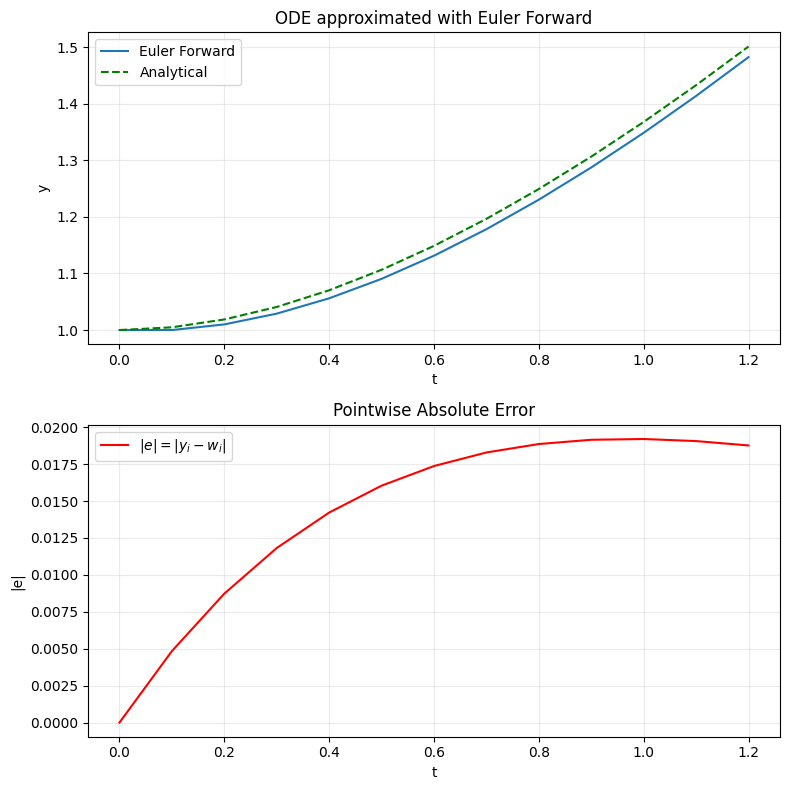

ANSWER C) Euler results error at t=T=1.2: 0.0188


In [119]:
def ODE1(t: float, y: float) -> float:
    return 1 + t - y


def ODE1_actual(t):
    return np.exp(-t) + t


y0 = 1
domain = [0, 1.2]
h = 0.1

results: EulerResult = euler_forward(ODE1, y0, domain=domain, h=h, exact=ODE1_actual)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
print("ANSWER B)")
# Top plot: solution
ax1.plot(results.t, results.y, label="Euler Forward")
ax1.plot(
    results.t, results.y_exact, color="green", linestyle="dashed", label="Analytical"
)
ax1.set_xlabel("t")
ax1.set_ylabel("y")
ax1.set_title("ODE approximated with Euler Forward")
ax1.grid(True, alpha=0.25)
ax1.legend()

# Bottom plot: error
ax2.plot(results.t, results.e_i, color="red", label=r"$|e| = |y_i - w_i|$")
ax2.set_xlabel("t")
ax2.set_ylabel("|e|")
ax2.set_title("Pointwise Absolute Error")
ax2.grid(True, alpha=0.25)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"ANSWER C) Euler results error at t=T=1.2: {results.e_i[-1]:1.4f}")

___
# F2)

## F2.a, b)

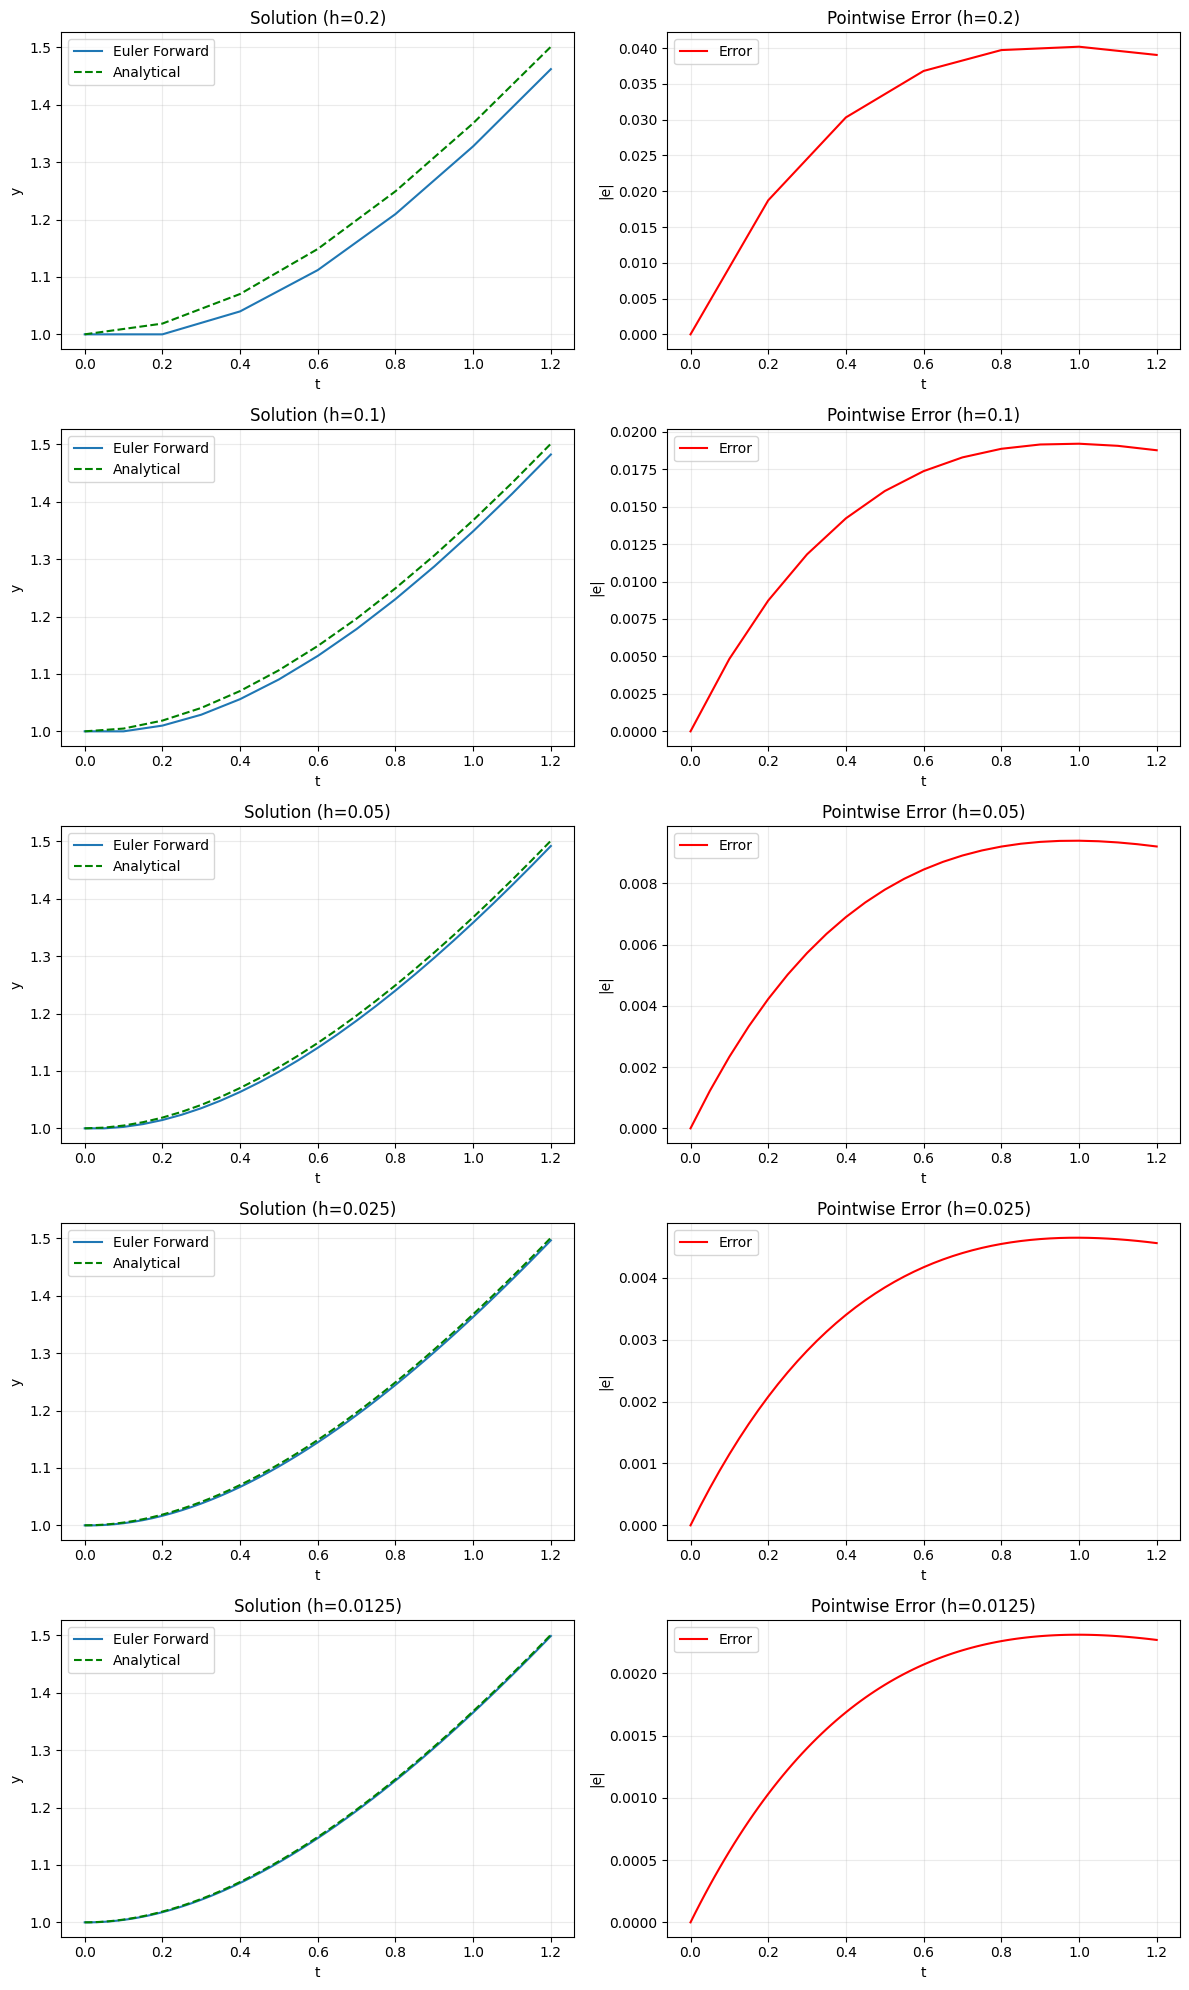

ANSWER B)
h          Max Error            Final Error         
--------------------------------------------------
0.2        0.040199             0.039050            
0.1        0.019201             0.018765            
0.05       0.009394             0.009205            
0.025      0.004647             0.004560            
0.0125     0.002311             0.002269            


In [120]:
convergence_results = []

h_values = [0.2, 0.1, 0.05, 0.025, 0.0125]


for h in h_values:
    convergence_results.append(
        euler_forward(ODE1, y0, domain=domain, h=h, exact=ODE1_actual)
    )

fig, axes = plt.subplots(len(h_values), 2, figsize=(12, 4 * len(h_values)))

for i, (h, result) in enumerate(zip(h_values, convergence_results)):
    # Solution plots
    axes[i, 0].plot(result.t, result.y, label="Euler Forward")
    axes[i, 0].plot(
        result.t, result.y_exact, color="green", linestyle="dashed", label="Analytical"
    )
    axes[i, 0].set_title(f"Solution (h={h})")
    axes[i, 0].set_xlabel("t")
    axes[i, 0].set_ylabel("y")
    axes[i, 0].grid(True, alpha=0.25)
    axes[i, 0].legend()

    # Error plots
    axes[i, 1].plot(result.t, result.e_i, color="red", label="Error")
    axes[i, 1].set_title(f"Pointwise Error (h={h})")
    axes[i, 1].set_xlabel("t")
    axes[i, 1].set_ylabel("|e|")
    axes[i, 1].grid(True, alpha=0.25)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

print("ANSWER B)")
print(f"{'h':<10} {'Max Error':<20} {'Final Error':<20}")
print("-" * 50)
for h, result in zip(h_values, convergence_results):
    print(f"{h:<10} {max(result.e_i):<20.6f} {result.e_i[-1]:<20.6f}")


## F2.c)

$$p \approx \log\left(\frac{e_{k,h}}{e_{k,h/2}}\right) \cdot \frac{1}{\log(2)}$$

In [121]:
convergence_results = []
h_values = [0.2, 0.1, 0.05, 0.025, 0.0125]

for h in h_values:
    convergence_results.append(
        euler_forward(ODE1, y0, domain=domain, h=h, exact=ODE1_actual)
    )

convergences = []
for i in range(len(convergence_results) - 1):
    e_h = convergence_results[i].e_i[-1]
    e_h2 = convergence_results[i + 1].e_i[-1]
    p = np.log2(e_h / e_h2)
    convergences.append(p)

for i, p in enumerate(convergences):
    print(f"h={h_values[i]:.4f} -> h/2={h_values[i + 1]:.4f} : p={p:.3f}")

h=0.2000 -> h/2=0.1000 : p=1.057
h=0.1000 -> h/2=0.0500 : p=1.028
h=0.0500 -> h/2=0.0250 : p=1.013
h=0.0250 -> h/2=0.0125 : p=1.007


___
# T1)

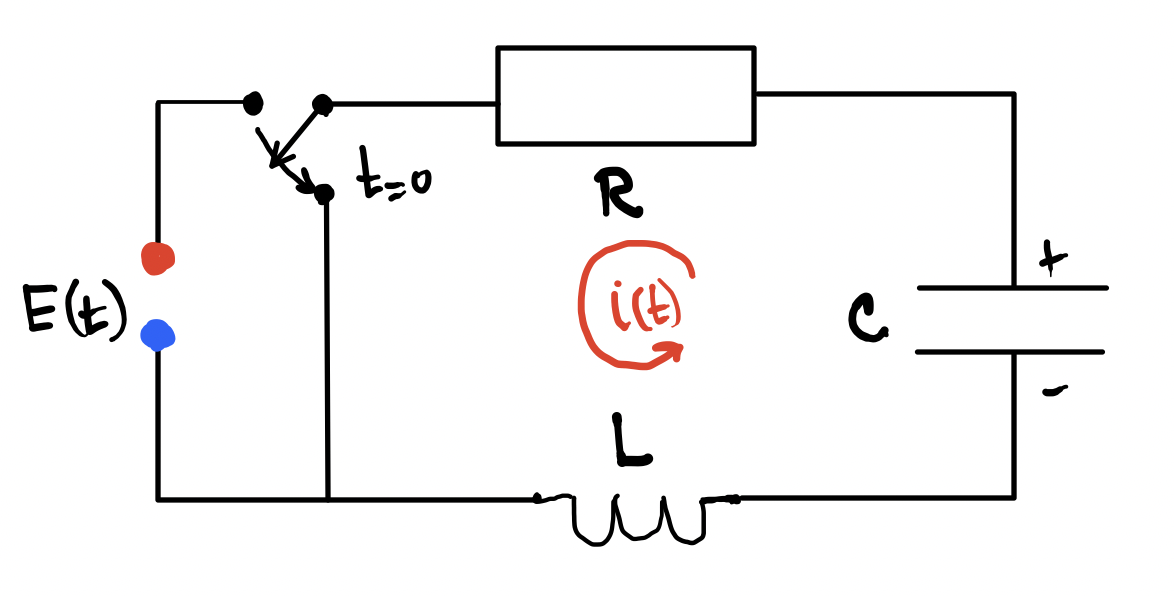

### T1.a)

DE for the charge $q(t)$ is:

$$\text{DE2:}\quad L\frac{d^2q}{dt^2} + R\frac{dq}{dt} + \frac{1}{C}q = 0$$

Introduce the substitution $i = \frac{dq}{dt}$ and rearrange:

$$\text{DE2*:} \quad \frac{di}{dt} = -\frac{R}{L}i - \frac{1}{LC}q$$

Rewrite in vectorform $\frac{d}{dt}y = F(t, y)$ where $y = \begin{pmatrix} q \\ i \end{pmatrix}$:

$$\frac{d}{dt}y = F(t, y) = \begin{pmatrix} i \\ -\dfrac{R}{L}i - \dfrac{1}{LC}q \end{pmatrix}$$

Note that the initial charge at $t=0$ for the condensator was $Q_0$, we therefore get: 
$$\text{IC:} \quad y(0) = \begin{pmatrix} Q_0 \\ 0 \end{pmatrix}$$


### T1.b)